# TUGAS MANDIRI

### A. Membangun Struktur Direktori HDFS

In [ ]:
# Membuat folder raw dan processed di HDFS
!hdfs dfs -mkdir -p /user/rindani/ecommerce/raw
!hdfs dfs -mkdir -p /user/rindani/ecommerce/processed

# Verfikasi folder yang telah dibuat
!hdfs dfs -ls /user/rindani/ecommerce

### B. Mengunggah Data Mentah ke HDFS

In [3]:
# Upload ketiga file CVS ke folder raw di HDFS
!hdfs dfs -put transaksi_magelang.csv /user/rindani/ecommerce/raw/
!hdfs dfs -put transaksi_yogyakarta.csv /user/rindani/ecommerce/raw/
!hdfs dfs -put transaksi_semarang.csv /user/rindani/ecommerce/raw

# Cek daftar file dan ukurannya di HDFS
!hdfs dfs -ls -h /user/rindani/ecommerce/raw

put: `/user/rindani/ecommerce/raw/transaksi_magelang.csv': File exists
put: `/user/rindani/ecommerce/raw/transaksi_yogyakarta.csv': File exists
put: `/user/rindani/ecommerce/raw/transaksi_semarang.csv': File exists
Found 3 items
-rw-r--r--   1 rindani supergroup     12.0 K 2026-09-10 07:47 /user/rindani/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 rindani supergroup     11.9 K 2026-09-10 07:47 /user/rindani/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 rindani supergroup     12.4 K 2026-09-10 07:47 /user/rindani/ecommerce/raw/transaksi_yogyakarta.csv


### C. Membaca Kembali dan Menggabungkan Data dari HDFS

In [6]:
import io
import subprocess
import pandas as pd

# Fungsi untuk membaca berkas dari HDFS
def read_hdfs_csv(hdfs_path):
    cmd = f"hdfs dfs -cat {hdfs_path}"
    output = subprocess.check_output(cmd, shell=True)
    return pd.read_csv(io.BytesIO(output))

# Membaca data dari HDFS
path_raw ="/user/rindani/ecommerce/raw"
df_magelang = read_hdfs_csv(f"{path_raw}/transaksi_magelang.csv")
df_yogya = read_hdfs_csv(f"{path_raw}/transaksi_yogyakarta.csv")
df_semarang = read_hdfs_csv(f"{path_raw}/transaksi_semarang.csv")

# Menggabungkan ketiga dataframe
df_gabungan = pd.concat(
    [df_magelang, df_yogya, df_semarang], ignore_index=True
)

# Menampilkan jumlah baris perkota
print("Jumlah transaksi per kota: ")
print(df_gabungan["kota"].value_counts())

Jumlah transaksi per kota: 
kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


### D. Mengolah dan Download Hasil Processed

In [9]:
# 1. Hitung total pendapatan
df_gabungan["total_pendapatan"] = (
    df_gabungan["unit_terjual"] * df_gabungan["harga_satuan"]
)

# 2. Buat tabel ringkasan total pendapatan
df_ringkasan = (
    df_gabungan.groupby(["kota", "kategori"])["total_pendapatan"]
    .sum()
    .reset_index()
)

# 3. Simpan sementara ke lokal
df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
df_ringkasan.to_csv("ringkasan_kota_kategori.csv", index=False)

# 4. Upload file hasil ke folder processed di HDFS
!hdfs dfs -put -f data_gabungan_bersih.csv /user/rindani/ecommerce/processed/
!hdfs dfs -put -f ringkasan_kota_kategori.csv /user/rindani/ecommerce/processed/

# 5. Verfikasi isi folder processed
!hdfs dfs -ls /user/rindani/ecommerce/processed

Found 2 items
-rw-r--r--   1 rindani supergroup      41257 2026-09-10 08:16 /user/rindani/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 rindani supergroup        530 2026-09-10 08:16 /user/rindani/ecommerce/processed/ringkasan_kota_kategori.csv


### E. Dokumetasi dan Refleksi

### 1. Screenshot NameNode Web UI

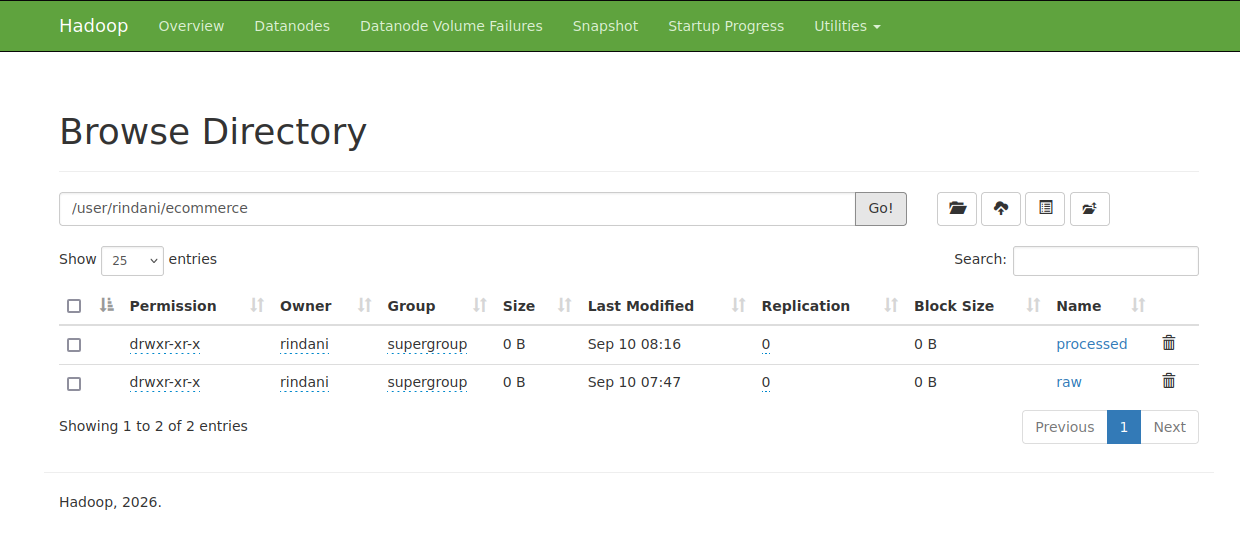

### 2. Tulisan Reflektif
Keuntungan pemisahan data mentah dan data olahan : Memisahkan penyimpanan data mentah (*raw*) dan data hasil olahan (*processed*) di HDFS sangat pentinguntuk menjaga keaslian data asli (*data lineage*). Aapabila terjadi kesalahan logika pemrosesan atau perubahan kebutuhan analisis di masa depan, data mentah tetap utuh dan dapat diproses ulang kapan saja tanpa risiko hilang. 
Selain itu, struktur ini meningkatkan efisiensi kerja tim *data analyst* lain karena mereka dapat langsung memanfaatkan data yang sudah bersih di folder *processed* tanpa perlu mengatur ulang proses pembersihan data (*data cleaning*). Pemisahan folder ini juga membuat tata kelola data (*data governance*) di dalam *data lake* menjadi lebih teratur, aman, dan mudah dikelola.